## Comprensión de datos
Analizaremos el conjunto de datos para obtener información sobre su estructura, características y problemas potenciales.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../../data/raw/online_retail_II.csv" , encoding="ISO-8859-1")

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


El conjunto de datos contiene 541.910 filas y 7 columnas. Los tipos de datos de las columnas son los siguientes:

- `Invoice`: cadena no nula
- `StockCode`: cadena no nula
- `Description`: cadena no nula
- `Quantity`: entero no nulo64
- `InvoiceDate`: cadena no nula
- `Price`: flotador no nulo64
- `Customer ID`: flotador no nulo64
- `Country`: cadena no nula

---

Podemos encontrar algunos problemas con los datos, como por ejemplo:
- La columna `InvoiceDate` está en formato de cadena, por lo que es posible que sea necesario convertirla a un formato de fecha y hora para su análisis.
- La columna `Customer ID` es un flotante, que puede necesitar convertirse a un formato de número entero o cadena para su análisis.
- La columna `Description` puede contener valores faltantes o inconsistentes que deben abordarse.

In [3]:
categoric_columns = df.select_dtypes(include=['str']).columns

df[categoric_columns].describe(include='all').T

,count,unique,top,freq
Invoice,541910,25900,573585,1114
StockCode,541910,4070,85123A,2313
Description,540456,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541910,23260,10/31/11 14:41,1114
Country,541910,38,United Kingdom,495478


## Resumen

Podemos analizar las columnas categóricas para comprender los valores y distribuciones únicos de estas características. Esto nos ayudará a identificar posibles problemas o patrones en los datos.
- `Country`: Los datos contienen 38 países únicos, siendo el más común el Reino Unido con 495478 entradas.
- `Description`: Los datos contienen 4223 descripciones únicas, siendo la más común "WHITE HANGING HEART T-LIGHT HOLDER" con 2369 entradas.
- `StockCode`: Los datos contienen 4070 códigos de stock únicos, siendo el más común "85123A" con 2313 entradas.
- `Invoice`: Los datos contienen 25900 facturas únicas, siendo la más común "573585" con 1114 entradas.

### Nota
No estamos analizando las columnas InvoiceDate e ID de cliente. Primero, necesitaremos convertir la columna InvoiceDate a un formato de fecha y hora y la columna Customer ID a un formato de número entero o cadena para su análisis. Una vez realizadas estas conversiones, también podemos analizar estas columnas.

In [4]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541910.0,9.552234,218.080957,-80995.00,1.00,3.00,10.00,80995.0
Price,541910.0,4.611138,96.759765,-11062.06,1.25,2.08,4.13,38970.0
Customer ID,406830.0,15287.684160,1713.603074,12346.00,13953.00,15152.00,16791.00,18287.0


## Resumen

Podemos analizar las columnas numéricas para comprender las distribuciones y estadísticas de estas características. Esto nos ayudará a identificar posibles problemas o patrones en los datos.

- `Quantity`: Los datos contienen una amplia gama de cantidades, con un valor mínimo de -80995 y un valor máximo de 80995. La cantidad media es 9,55 y la desviación estándar es 218. Los valores negativos pueden indicar devoluciones o cancelaciones, que deben investigarse más a fondo.
- `Price`: Los datos contienen una amplia gama de precios, con un valor mínimo de -11062,06 y un valor máximo de 38970. El precio medio es 4,61 y la desviación estándar es 96,76. Los valores negativos pueden indicar reembolsos o errores en los datos, que deben investigarse más a fondo.
- `Customer ID`: los ID de cliente parecen ser identificadores únicos para cada cliente, que se pueden utilizar para análisis y segmentación.

### Nota

Como mencionamos antes, las columnas de cantidad y precio contienen valores negativos, que pueden indicar devoluciones o cancelaciones. Deberíamos investigar estos valores más a fondo para comprender su impacto en el análisis. Además, debemos verificar si hay valores atípicos o anomalías en los datos que puedan afectar los resultados de nuestro análisis.

In [5]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/10 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/10 10:24,1.65,17548.0,United Kingdom
937,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/10 12:38,4.25,17897.0,United Kingdom


Dijimos antes que los `Quantity` tienen valores negativos, lo que puede indicar devoluciones o cancelaciones. Una hipótesis sencilla que podemos hacer es que las Facturas que empiezan con la letra “C” son devoluciones o cancelaciones. Comprobemos si esta hipótesis es cierta filtrando los datos de las facturas que comienzan con "C" y comprobando los valores de cantidad.

In [6]:
print("Number of negative Quantity values:", df[df["Quantity"] < 0].shape[0])
print("Number of invoices starting with 'C':", df[df["Invoice"].str.startswith("C")].shape[0])
print("Number of negative Quantity values in invoices starting with 'C':", df[(df["Quantity"] < 0) & (df["Invoice"].str.startswith("C"))].shape[0])

Number of negative Quantity values: 10624
Number of invoices starting with 'C': 9288
Number of negative Quantity values in invoices starting with 'C': 9288


Entonces es posible que los valores negativos en la columna `Quantity` estén relacionados con devoluciones o cancelaciones porque hay 9288 valores en la columna `Quantity` que son negativos y hay 9288 facturas que comienzan con la letra "C". Esto sugiere que los valores negativos en la columna `Quantity` pueden estar asociados con devoluciones o cancelaciones, ya que es probable que estas facturas representen transacciones en las que los artículos fueron devueltos o cancelados. Sin embargo, hay 10624 en la columna `Quantity` que son negativas, pero solo 9288 facturas que comienzan con la letra "C".

Esto significa que hay 1336 valores negativos en la columna `Quantity` que no están asociados con facturas que comienzan con "C". Por lo tanto, si bien los datos respaldan la hipótesis de que las facturas que comienzan con "C" son devoluciones o cancelaciones, no es una explicación completa de todos los valores negativos en la columna `Quantity`. Es posible que sea necesario realizar más investigaciones para comprender las razones de estos valores negativos adicionales.

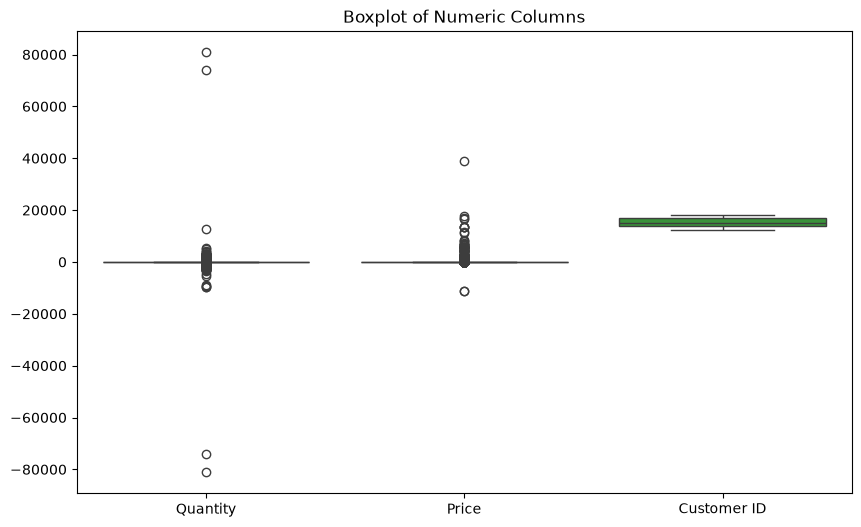

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df[numeric_columns], ax=ax)
ax.set_title('Boxplot of Numeric Columns')

plt.show()

## Resumen

Estos boxplots nos muestran la distribución de las columnas numéricas, algunos puntos quiero resaltar:
- La columna `Quantity` tiene una amplia gama de valores, con valores atípicos extremos graves tanto en dirección positiva como negativa. La gran mayoría de los datos se concentra en gran medida alrededor de cero (la mediana), mientras que los numerosos valores atípicos sugieren posibles devoluciones, cancelaciones o errores en el ingreso de datos que deberían investigarse más a fondo.
- La columna`Price`también muestra una amplia gama de valores, con valores atípicos extremos tanto en la cola superior como en valores negativos. La mayoría de las transacciones se agrupan estrechamente en torno a un precio base bajo, lo que significa que esos puntos de alto valor o cifras negativas pueden estar asociados con artículos especiales de alto valor, ajustes o errores que requieren una inspección más cercana.

Quantity Value Skewness: 4.07476318727056
Price Value Skewness: 2.0725573839450924


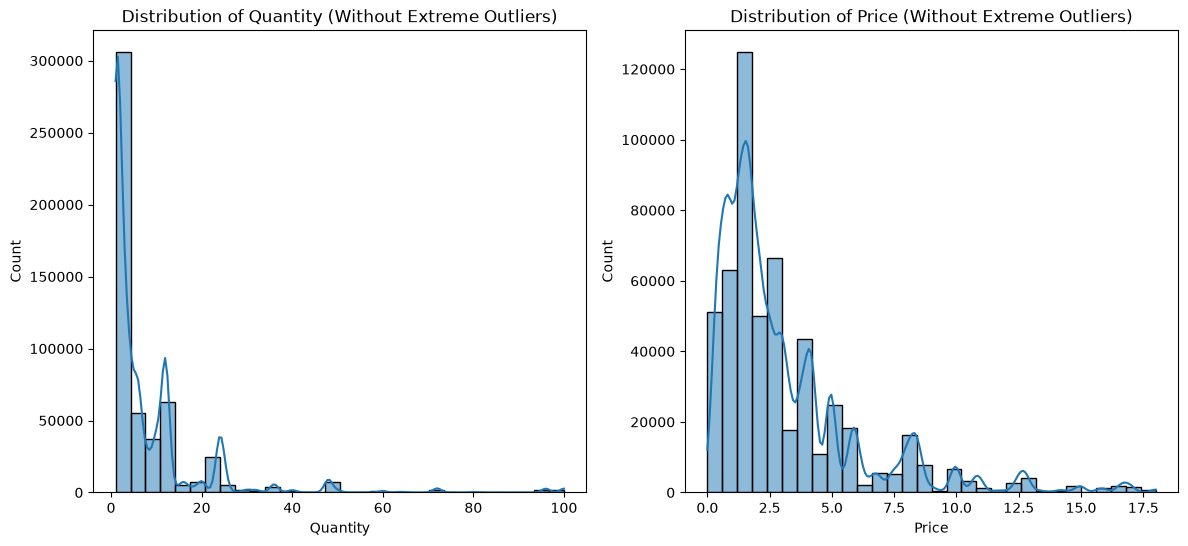

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

q_limit_qty = df["Quantity"].quantile(0.99)
q_limit_price = df["Price"].quantile(0.99)

filtered_qty = df[(df["Quantity"] > 0) & (df["Quantity"] <= q_limit_qty)]
filtered_price = df[(df["Price"] > 0) & (df["Price"] <= q_limit_price)]

sns.histplot(filtered_qty["Quantity"], bins=30, ax=axes[0], kde=True)
sns.histplot(filtered_price["Price"], bins=30, ax=axes[1], kde=True)

axes[0].set_title("Distribution of Quantity (Without Extreme Outliers)")
axes[1].set_title("Distribution of Price (Without Extreme Outliers)")

print("Quantity Value Skewness:", filtered_qty["Quantity"].skew())
print("Price Value Skewness:", filtered_price["Price"].skew())
plt.show()

## Resumen

Sin valores atípicos extremos, las distribuciones de `Quantity` y `Price` nos dan una imagen más clara de la distribución de estas características. En primer lugar, la distribución `Quantity` está muy sesgada a la derecha, y la mayoría de las transacciones tienen una cantidad entre 1 y 3. La distribución `Price` también está sesgada a la derecha, y la mayoría de las transacciones tienen un precio inferior a aproximadamente 5 dólares. Estas distribuciones sugieren que la mayoría de las transacciones involucran pequeñas cantidades y artículos de bajo precio, mientras que los valores atípicos extremos pueden representar casos especiales o errores en los datos.

Podemos analizar la asimetría de las columnas `Quantity` y `Price` para cuantificar el grado de asimetría en sus distribuciones. Una asimetría positiva indica una distribución sesgada hacia la derecha, mientras que una asimetría negativa indica una distribución sesgada hacia la izquierda. Los valores de asimetría para los datos filtrados son los siguientes:

- `Quantity`: 4.07 (sesgado a la derecha)
- `Price`: 2.07 (sesgado a la derecha)

Por lo tanto, las columnas `Quantity` y `Price` exhiben distribuciones sesgadas a la derecha, lo que indica que la mayoría de las transacciones involucran pequeñas cantidades y artículos de bajo precio, mientras que los valores atípicos extremos pueden representar casos especiales o errores en los datos.

# Informe de comprensión de datos: exploración inicial e hipótesis

## 1. Resumen ejecutivo
Este documento resume la exploración inicial del conjunto de datos. El objetivo es establecer una comprensión fundamental de la estructura y calidad de los datos, conectando estas características con escenarios comerciales potenciales antes de pasar a las fases de preparación y calidad de los datos.

## 2. Perspectiva empresarial y contexto del conjunto de datos
* **Naturaleza empresarial**: El conjunto de datos parece representar datos de transacciones minoristas (por ejemplo, comercio electrónico o punto de venta) como hemos visto antes porque el nombre y la estructura del conjunto de datos son consistentes con dichos datos.
* **Alcance de los datos**: Contiene funciones esenciales para el análisis de ventas, incluidos identificadores únicos, marcas de tiempo, descripciones de productos, cantidades y precios.
* **Evaluación inicial**: Los datos son consistentes con un registro de transacciones, lo que permite un posible análisis de rfm (reciente, frecuencia, monetario) y la segmentación de clientes que exploraremos en etapas posteriores.

## 3. Observaciones clave (anomalías y patrones)
* **Valores anómalos**: Se identificaron valores negativos significativos en las columnas`Quantity`y `Price`.
* **Integridad de datos**: Faltan entradas en los campos`Description`y `Customer ID`.
* **Discrepancias de formato**:`InvoiceDate`se almacena actualmente como una cadena y`Customer ID`se representa como un decimal; ambos requieren una transformación futura.

## 4. Hipótesis iniciales
A partir de la inspección preliminar se han formulado las siguientes hipótesis para su validación en las siguientes etapas:

| Hipótesis | Descripción |
| :--- | :--- |
| **Valores negativos** | Es probable que representen **cancelaciones o devoluciones de pedidos** en lugar de errores de entrada de datos, dada su distribución. |
| **Valores faltantes** | Las entradas`Customer ID`que faltan pueden indicar **transacciones de pago como invitado**, mientras que las entradas`Descriptions`que faltan podrían sugerir fallas en el sistema o códigos de producto no válidos. |
| **Necesidades de preparación de datos** | El conjunto de datos es estructuralmente sólido para el análisis, pero requiere **estandarización** (fecha de fundición y tipos de ID) y **filtrado** (manejo de valores nulos) para garantizar un modelado posterior preciso. |

## 5. Próximos pasos
* Evaluación de la calidad de los datos: cuantificar el impacto de los valores faltantes y realizar un análisis de frecuencia sobre cantidades negativas para confirmar la hipótesis de "cancelación".
* Preparación de Datos: Proceder con la transformación de tipos de columnas y la exclusión/imputación de registros no válidos en base a reglas de negocio derivadas de la etapa de validación.